---
---

#  Application Project - SingularIT
---
---

# Context
---

- Explaining the Project
- hypothesis final......

### <span style="color:yellow"> **--Imports & Settings--**</span> 
---

In [1]:
import pandas as pd
import numpy as np
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### <span style="color:lightgreen"> **-- Task - Data--**</span> 
---

### <span style="color:blue"> **Reading in the data to a pandas dataframe**</span> 


In [2]:
# Look for all ".json" files
results = glob.glob("results/*.json")
results

['results\\Diana-Hans.json',
 'results\\Diana-Magnus.json',
 'results\\Diana-Olga.json',
 'results\\Diana-Simon.json',
 'results\\Diana-Tanja.json',
 'results\\Hans-Magnus.json',
 'results\\Hans-Olga.json',
 'results\\Hans-Simon.json',
 'results\\Hans-Tanja.json',
 'results\\Magnus-Olga.json',
 'results\\Magnus-Simon.json',
 'results\\Magnus-Tanja.json',
 'results\\Olga-Simon.json',
 'results\\Olga-Tanja.json',
 'results\\Simon-Tanja.json']

In [3]:
file_list = []

for files in results:
    # Open files
    with open(files, "r") as file:
        data = json.load(file)

    events_list = []
    # Assign filename to "game" column
    game = os.path.basename(files).replace(".json", "")

    # Loop through the runs
    for run in data.get("runs", []):
        run_id = run["run_id"]
        player_1 = run["player_1"]
        player_2 = run["player_2"]
        # Loop through events
        for event in run.get("events", []):
            events_list.append({
                "game": game,
                "run_id": run_id,
                "player_1": player_1,
                "player_2": player_2,
                "timestamp": event["timestamp"],
                "player": event["player"],
                "event_type": event["type"],
                "bar": event.get("bar", pd.NA),
                "side": event.get("side", pd.NA),
                "is_goal": event.get("successful", False) #True if successful, False if not successful
            })

    # Convert to dataframe
    df_game = pd.DataFrame(events_list)
    file_list.append(df_game)

In [4]:
# Combine dataframes
timestamped_data = pd.concat(file_list, ignore_index=True)
print("Dataframe size:", len(timestamped_data))

Dataframe size: 29337


In [5]:
# Sorting by matchup, run and timestamp
timestamped_data = timestamped_data.sort_values(by=["game", "run_id", "timestamp"]).reset_index(drop=True)

In [6]:
# Create a new column "is_shot"
timestamped_data["is_shot"] = timestamped_data["event_type"] == "shot"

In [7]:
print(timestamped_data["event_type"].value_counts())
print(timestamped_data["player"].value_counts())

event_type
contact    22971
shot        6366
Name: count, dtype: int64
player
Olga      5969
Magnus    5230
Tanja     5100
Simon     5084
Hans      4051
Diana     3903
Name: count, dtype: int64


In [8]:
# Check results
print("Dataset shape:", timestamped_data.shape)
timestamped_data.head()

Dataset shape: (29337, 11)


,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,is_shot
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False,False
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False,False
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False,False
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True,True
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False,False


### <span style="color:orange"> **--Aggregated Version Where Rounds = Rows--**</span> 

In [9]:
def create_results_table(df):
    is_shot = (df['event_type'] == 'shot')
    is_goal = (df['is_goal'] == True)
    
    df['is_p1_goal'] = is_shot & is_goal & (df['player'] == df['player_1'])
    df['is_p2_goal'] = is_shot & is_goal & (df['player'] == df['player_2'])

    results = df.groupby(['game', 'run_id']).agg({
        'player_1': 'first',
        'player_2': 'first',
        'is_p1_goal': 'sum',
        'is_p2_goal': 'sum'
    }).reset_index()

    results = results.rename(columns={
        'is_p1_goal': 'points_player_1',
        'is_p2_goal': 'points_player_2'
    })

    results['winner'] = np.where(
        results['points_player_2'] > results['points_player_1'], results['player_2'], results['player_1'])
    
    results['loser'] = np.where(
        results['points_player_2'] > results['points_player_1'], results['player_1'], results['player_2'])

    df.drop(columns=['is_p1_goal', 'is_p2_goal'], inplace=True)

    return results

results_table = create_results_table(timestamped_data)

results_table

,game,run_id,player_1,player_2,points_player_1,points_player_2,winner,loser
0,Diana-Hans,0,Diana,Hans,10,5,Diana,Hans
1,Diana-Hans,1,Diana,Hans,10,5,Diana,Hans
2,Diana-Hans,2,Diana,Hans,10,5,Diana,Hans
3,Diana-Hans,3,Diana,Hans,10,4,Diana,Hans
4,Diana-Hans,4,Diana,Hans,10,5,Diana,Hans
...,...,...,...,...,...,...,...,...
70,Simon-Tanja,0,Simon,Tanja,10,8,Simon,Tanja
71,Simon-Tanja,1,Simon,Tanja,9,10,Tanja,Simon
72,Simon-Tanja,2,Simon,Tanja,5,10,Tanja,Simon
73,Simon-Tanja,3,Simon,Tanja,10,6,Simon,Tanja


In [10]:
results_table['winner'].value_counts().reset_index()

,winner,count
0,Diana,22
1,Simon,17
2,Olga,15
3,Magnus,10
4,Tanja,8
5,Hans,3


In [11]:
win_counts = results_table.groupby(['winner', 'loser']).size().reset_index(name='wins')
win_matrix = win_counts.pivot(index='winner', columns='loser', values='wins')
all_players = sorted(list(set(results_table['winner']) | set(results_table['loser']))) 
win_matrix.reindex(index=all_players, columns=all_players, fill_value=0)

loser,Diana,Hans,Magnus,Olga,Simon,Tanja
winner,,,,,,
Diana,NaN,5.0,4.0,5.0,3.0,5.0
Hans,NaN,NaN,NaN,1.0,NaN,2.0
Magnus,1.0,5.0,NaN,1.0,1.0,2.0
Olga,NaN,4.0,4.0,NaN,2.0,5.0
Simon,2.0,5.0,4.0,3.0,NaN,3.0
Tanja,NaN,3.0,3.0,NaN,2.0,NaN


In [12]:
timestamped_data['round'] = timestamped_data.groupby(['game', 'run_id'])['is_goal'].shift(fill_value=False).cumsum() + 1 #counts up whenever the previous row was a goal (shift function moves it down 1 row)
timestamped_data['is_contact_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 1 contact
timestamped_data['is_contact_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 2 contact
timestamped_data['is_shot_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 1 shot
timestamped_data['is_shot_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 2 shot

round_data = timestamped_data.groupby(['game', 'run_id', 'round']).agg( #aggregating the data for each round
    start=('timestamp', 'min'), #minimum timestamp in all of the rows for a round -> minimum -> first row
    end=('timestamp', 'max'), #maximum timestamp in all of the rows for a round -> maximum -> last row
    player_1=('player_1', 'first'), #just takes the value of the first row of a round -> doesn't matter because it's the same in all of the rows
    player_2=('player_2', 'first'), 
    contacts_p1=('is_contact_p1', 'sum'), #sum of all the contacts for player 1 (count of True in the boolean column see above)
    contacts_p2=('is_contact_p2', 'sum'), 
    shots_p1=('is_shot_p1', 'sum'),
    shots_p2=('is_shot_p2', 'sum')
).reset_index()

round_data.columns = ['game', 'run_id', 'round', 'start', 'end', 'player_1', 'player_2', 'contacts_p1', 'contacts_p2', 'shots_p1', 'shots_p2']

winners = timestamped_data[timestamped_data['is_goal']].set_index(['game', 'run_id', 'round'])['player'] #filters the goal rows and then extracts the player who shot the goal (=winner) for each round
round_data = round_data.join(winners, on=['game', 'run_id', 'round']).rename(columns={'player': 'round_winner'}) #joins the winner on game, run_id and round

round_data['duration'] = round_data['end'] - round_data['start'] #calculating duration
round_data['p1_won_round'] = (round_data['round_winner'] == round_data['player_1']) #boolean column whether player 1 won the round
round_data['p2_won_round'] = (round_data['round_winner'] == round_data['player_2']) #boolean columns whether player 2 won the round

round_data['points_p1'] = round_data.groupby(['game', 'run_id'])['p1_won_round'].transform('cumsum') #counts up if player 1 won
round_data['points_p2'] = round_data.groupby(['game', 'run_id'])['p2_won_round'].transform('cumsum') #counts up if player 2 won

round_data.drop(columns=['game','p1_won_round', 'p2_won_round'], inplace=True) #dropping unneccessary columns

In [13]:
round_data

,run_id,round,start,end,player_1,player_2,contacts_p1,contacts_p2,shots_p1,shots_p2,round_winner,duration,points_p1,points_p2
0,0,1,2.985530,10.453081,Diana,Hans,2,1,0,1,Hans,7.467551,0,1
1,0,2,20.291921,51.365341,Diana,Hans,5,5,3,2,Diana,31.073420,1,1
2,0,3,56.560030,150.898025,Diana,Hans,15,17,5,7,Diana,94.337994,2,1
3,0,4,164.168779,178.463446,Diana,Hans,3,2,3,1,Diana,14.294667,3,1
4,0,5,191.487753,208.643816,Diana,Hans,4,5,3,2,Hans,17.156064,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1214,4,1141,608.090735,738.918799,Simon,Tanja,22,19,9,5,Tanja,130.828064,6,5
1215,4,1142,743.100045,786.364901,Simon,Tanja,10,4,2,1,Simon,43.264856,7,5
1216,4,1143,790.162325,844.426036,Simon,Tanja,13,6,5,3,Simon,54.263711,8,5
1217,4,1144,848.255402,898.807072,Simon,Tanja,7,8,2,4,Simon,50.551670,9,5


# EDA - all players

### Are there differences in the amount of contacts or shots depending on who plays against who?

In [14]:
# Count events per game
run_counts = timestamped_data.groupby(["game", "run_id", "event_type"]).size()
# Turn event types into columns
run_counts = run_counts.unstack(fill_value=0).reset_index()
# Avg contacts & shots per matchup
avg_counts = run_counts.groupby("game")[["contact", "shot"]].mean().reset_index()
# Add total events column
avg_counts["total"] = avg_counts["contact"] + avg_counts["shot"]
# Sort by total (highest first)
avg_counts = avg_counts.sort_values(by="total", ascending=False)

# Display results
print("Average Events per Game by Matchup:")
display(avg_counts.round(1))

Average Events per Game by Matchup:


event_type,game,contact,shot,total
13,Olga-Tanja,419.0,72.8,491.8
11,Magnus-Tanja,381.6,97.6,479.2
9,Magnus-Olga,396.4,66.0,462.4
10,Magnus-Simon,331.6,104.6,436.2
12,Olga-Simon,354.0,81.0,435.0
8,Hans-Tanja,317.8,105.8,423.6
14,Simon-Tanja,296.8,101.8,398.6
5,Hans-Magnus,288.4,99.0,387.4
6,Hans-Olga,302.0,68.8,370.8
4,Diana-Tanja,263.0,87.0,350.0


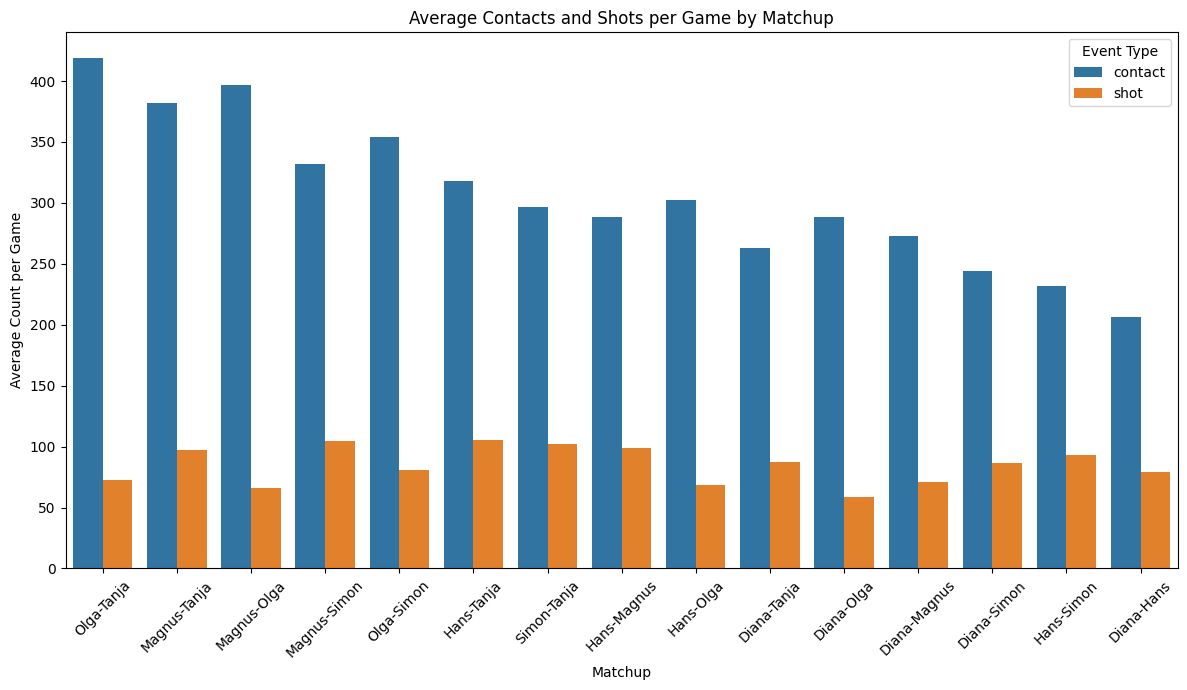

In [15]:
# Reshape data for plotting
plot_df = avg_counts.melt(
    id_vars="game",
    value_vars=["contact", "shot"],
    var_name="Event Type",
    value_name="Average Count per Game")

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    x="game",
    y="Average Count per Game",
    hue="Event Type")

# Axis labels
plt.xticks(rotation=45)
plt.title("Average Contacts and Shots per Game by Matchup")
plt.xlabel("Matchup")
plt.ylabel("Average Count per Game")
plt.tight_layout()
plt.show()

###  Shot Conversion

In [16]:
# Conversion rate is number of successful goals / shot.
timestamped_data['is_shot'] = timestamped_data['event_type'] == 'shot'

player_conversion_rate = timestamped_data.groupby('player').agg(shots=('is_shot','sum'), goals=('is_goal', 'sum')).reset_index()
player_conversion_rate['conversion_rate'] = (player_conversion_rate['goals'] / player_conversion_rate['shots'])


In [17]:
player_conversion_rate

,player,shots,goals,conversion_rate
0,Diana,944,240,0.254237
1,Hans,1247,162,0.129912
2,Magnus,1002,186,0.185629
3,Olga,664,223,0.335843
4,Simon,1368,219,0.160088
5,Tanja,1141,189,0.165644


Text(0.5, 1.0, 'Shot Conversion Rate for each player')

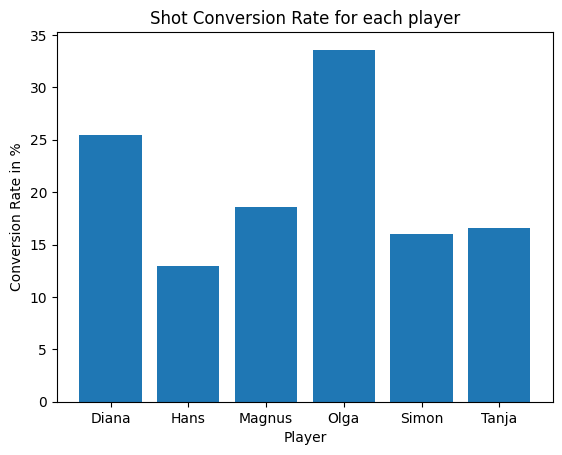

In [18]:
plt.figure()
plt.xlabel('Player')
plt.ylabel('Conversion Rate in %')
plt.bar(player_conversion_rate['player'], (player_conversion_rate['conversion_rate'] * 100))
plt.title('Shot Conversion Rate for each player')

### Round Duration by player shots? Does Longer Round = more shots taken?

Text(0.5, 1.0, 'Shorter Round = Less Shots ?')

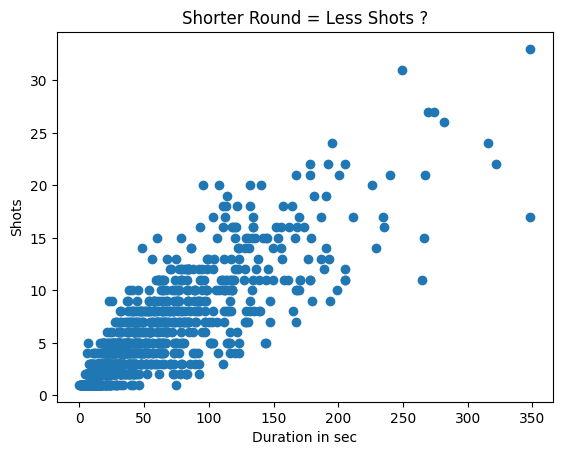

In [19]:
round_data['total_shots'] = (round_data['shots_p1'] + round_data['shots_p2'])
plt.scatter(round_data['duration'], round_data['total_shots'])
plt.xlabel('Duration in sec')
plt.ylabel("Shots")
plt.title('Shorter Round = Less Shots ?')

In [20]:
# Plotly Graph for the same...
fig = px.scatter(round_data, x='duration', y='total_shots', hover_data={'duration': True, 'player_1': True, 'player_2': True, 'total_shots': True, 'shots_p1': True, 'shots_p2': True},
                 title="Shot Duration", labels={'duration': 'Duration in sec'})
fig.show()

### Heatmaps

In [21]:
def plot_kicker_heatmap(matchup_names, df=None, ax=None):
    mask = (
        (df['game'] == matchup_names) & #filtering the data (no run_id -> all of the games for each matchup)
        (df['bar'].notna()) & 
        (df['side'].notna()) & 
        (df['event_type'] == 'contact') #only contacts 
    )

    game_data = df[mask].copy() #this is the df that gets used in this function

    p1name = game_data['player_1'].iloc[0] #extracting the player names
    p2name = game_data['player_2'].iloc[0]

    bar_order = ['Goal1', 'Defense1', 'Attack2', 'Middle1', 'Middle2', 'Attack1', 'Defense2', 'Goal2'] #order of the bars
    side_order = ['Left', 'Middle', 'Right'] #order of the sides

    counts = game_data.groupby(['bar', 'side']).size().unstack(fill_value=0) #counting how often each combination happens
    counts = counts.reindex(index=bar_order, columns=side_order, fill_value=0) #bringing it in the correct order
    
    total_actions = counts.values.sum() #summing up all of the values
    heatmap_percent = (counts / total_actions) * 100 #calculating in percent

    #for the y-axis labels: bars of player 1 on the left side, bars of player 2 on the right side
    left_labels = [b.replace('1', f' ({p1name})') if b.endswith('1') else '' for b in bar_order] #renaming e.g. "Attack1" to "Attack Diana" (player 1 name)
    right_labels = [b.replace('2', f' ({p2name})') if b.endswith('2') else '' for b in bar_order] #renaming for player 2 too

    if ax is None: #ax argument is for plotting multiple plots
        fig, ax = plt.subplots(figsize=(6, 8)) #if no ax provided -> just plotting for this one matchup

    sns.heatmap( #creating a heatmap
        heatmap_percent, 
        annot=True, 
        fmt=".1f", 
        cmap="Reds",
        linewidths=2, 
        linecolor='white',
        cbar=False,
        yticklabels=left_labels,
        ax=ax,
        vmin=0, 
        vmax=10 #10 percent is the maximum -> values above will have the same color
    )

    ax.set_yticklabels(left_labels, rotation=0, fontsize=9) #on the left side (y-axis) only the bars of player 1
    ax.set_xlabel("") #no "side" on the axis
    ax.set_ylabel("") #no "bar" on the axis

    ax2 = ax.twinx() #creating a second y-axis
    ax2.set_ylim(ax.get_ylim()) 
    ax2.set_yticks(ax.get_yticks()) #same height of the ticks
    ax2.set_yticklabels(right_labels, rotation=0, fontsize=9)
    ax2.set_ylabel("")

    ax.set_title(f"{matchup_names}\n({total_actions} actions, excluding goals)")
    ax.xaxis.tick_bottom()

    for t in ax.texts: #adds % signs
        if "%" not in t.get_text():
            t.set_text(t.get_text() + "%")

In [22]:
#plot_kicker_heatmap("Diana-Hans", timestamped_data)

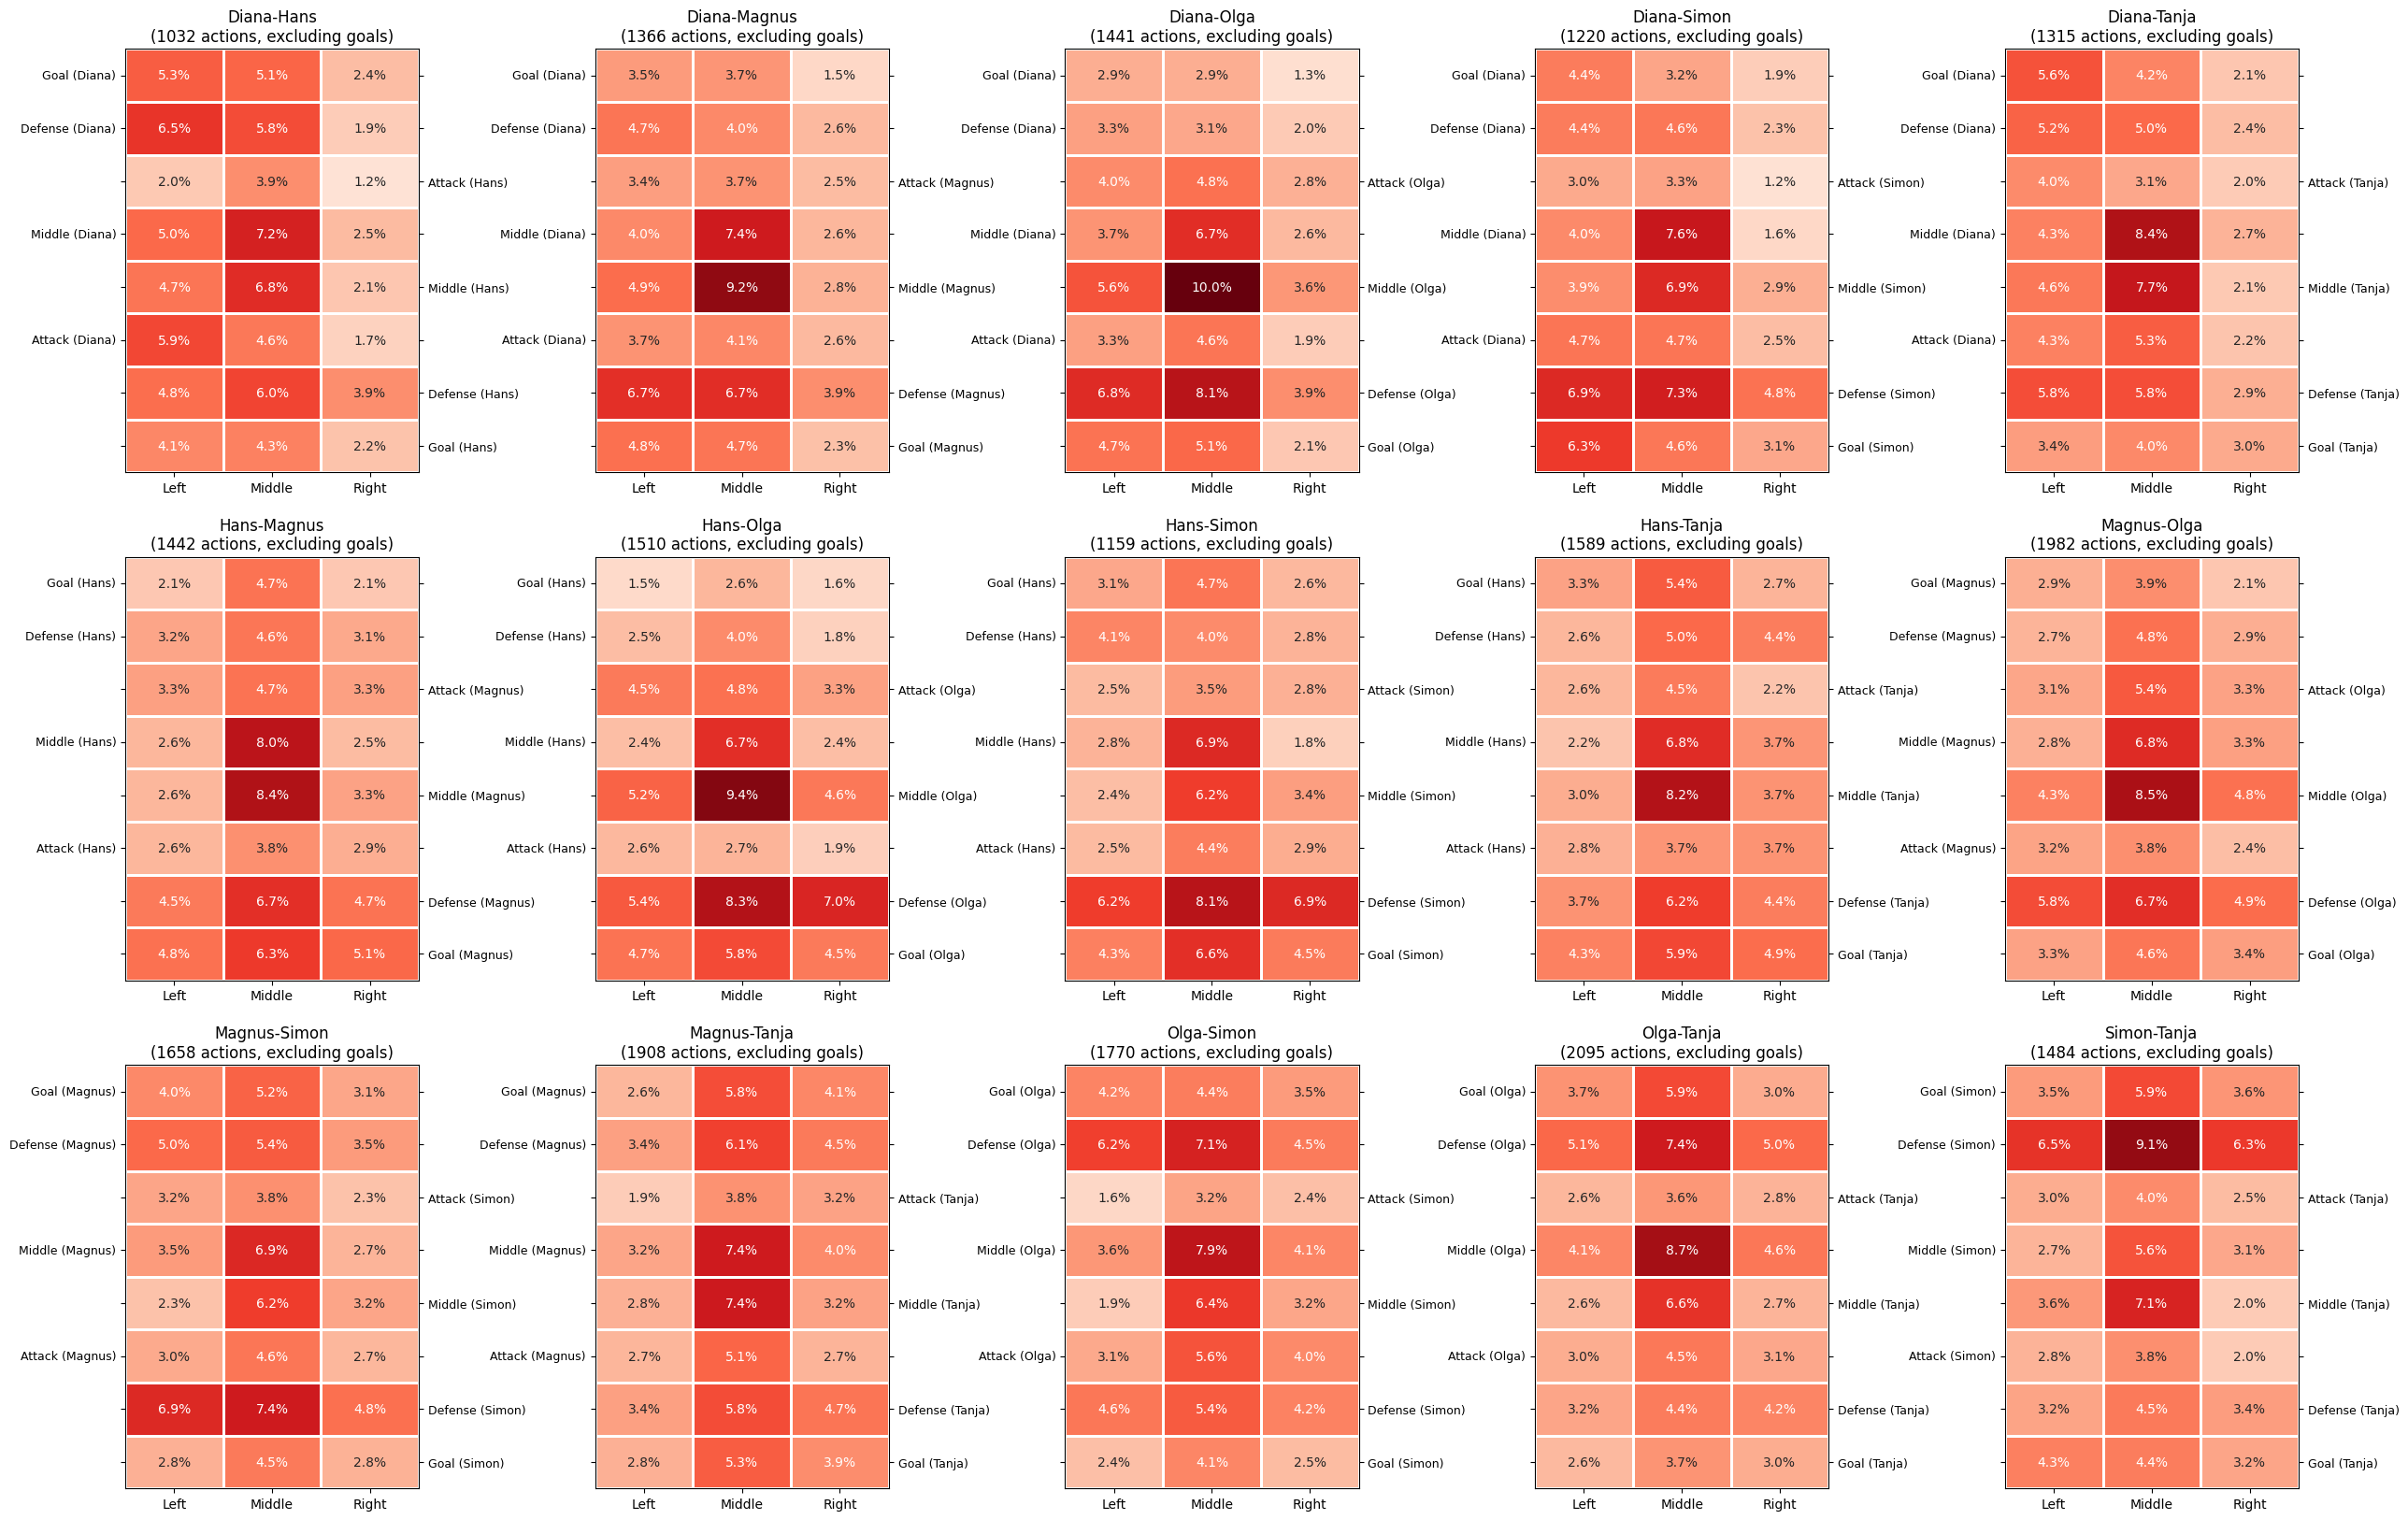

In [23]:
all_matchups = sorted(timestamped_data['game'].unique()) #finding all of the matchups (= "game" names)

fig, axes = plt.subplots(3, 5, figsize=(30, 20)) #3 rows, 5 columns
axes = axes.flatten()

for i, matchup in enumerate(all_matchups): #creating a plot for each matchup 
    plot_kicker_heatmap(matchup, df=timestamped_data, ax=axes[i]) #different ax for each plot -> used in the function

plt.subplots_adjust(hspace=0.2, wspace=0.6) #spaces between the plots
plt.show()

In [24]:
def plot_aggregated_player_profile(target_player, ax=None): #to aggregate the heatmap for a specific player
    mask = (timestamped_data['player_1'] == target_player) | (timestamped_data['player_2'] == target_player) #filtering for all of the games with that player
    player_data = timestamped_data[mask].copy() #using only games of that player
    
    def normalize_matchup(row): #the target player has to be player 1 in the plot -> changing that up when the target player is player 2 -> also changing the "side"
        current_bar = row['bar']
        current_side = row['side']

        if row['player_2'] == target_player:
            if pd.notna(current_bar):
                if '1' in current_bar: new_bar = current_bar.replace('1', '2')
                elif '2' in current_bar: new_bar = current_bar.replace('2', '1')
                else: new_bar = current_bar
            else:
                new_bar = current_bar

            if current_side == 'Left': new_side = 'Right' #mirroring the bars
            elif current_side == 'Right': new_side = 'Left'
            else: new_side = current_side

            return pd.Series([f"{target_player} vs Others", target_player, "Others", new_bar, new_side], #returns "new" data where the game name is "[target_player] vs Others"
                             index=['game', 'player_1', 'player_2', 'bar', 'side'])
        
        else:
            return pd.Series([f"{target_player} vs Others", target_player, "Others", current_bar, current_side], 
                             index=['game', 'player_1', 'player_2', 'bar', 'side'])

    norm_cols = player_data.apply(normalize_matchup, axis=1) #applying the normalize function
    player_data[['game', 'player_1', 'player_2', 'bar', 'side']] = norm_cols #changing the df

    plot_kicker_heatmap(f"{target_player} vs Others", df=player_data, ax=ax) #using the previous function for the "[target_player] vs Others" games in the new df

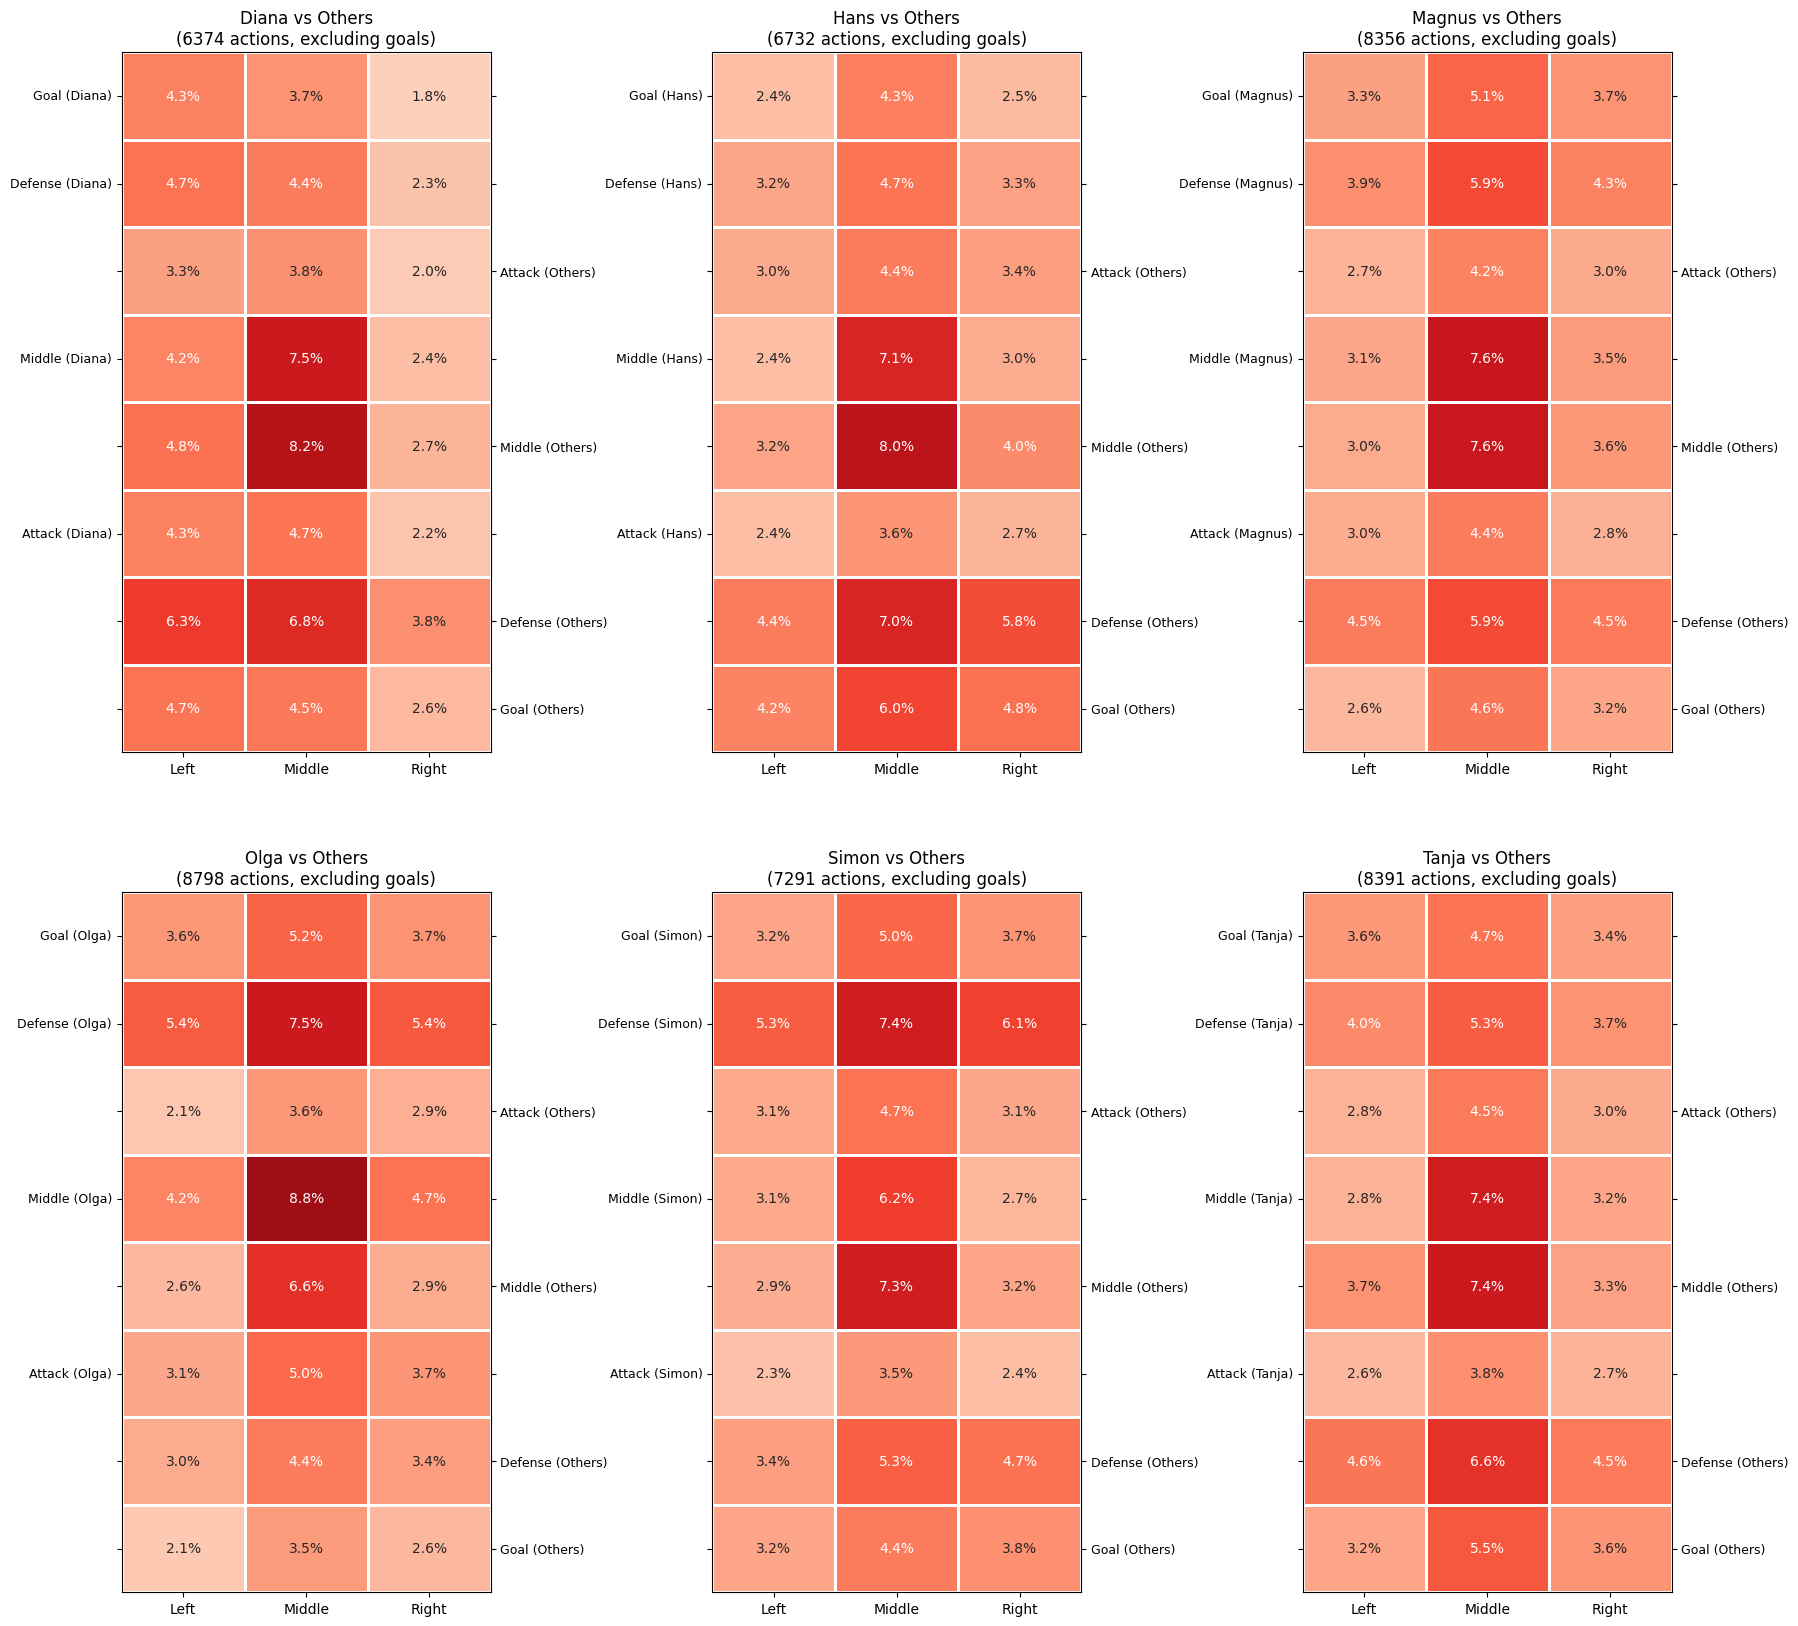

In [25]:
all_players = sorted(list(set(results_table['winner']) | set(results_table['loser']))) #list of all players

fig, axes = plt.subplots(2, 3, figsize=(20, 20)) #2 rows, 3 columns
axes_flat = axes.flatten()

for i, player in enumerate(sorted(all_players)): #creating the plot for each player
    plot_aggregated_player_profile(player, ax=axes_flat[i])

plt.subplots_adjust(wspace=0.6, hspace=0.2) #spaces between the plots
plt.show()

## Connecting goals to previous contacts

In [26]:
timestamped_data['prev_player'] = timestamped_data.groupby(['game', 'run_id'])['player'].shift(1) #shift(1) -> taking the row above
timestamped_data['prev_bar'] = timestamped_data.groupby(['game', 'run_id'])['bar'].shift(1)
timestamped_data['prev_side'] = timestamped_data.groupby(['game', 'run_id'])['side'].shift(1)
timestamped_data['prev_event'] = timestamped_data.groupby(['game', 'run_id'])['event_type'].shift(1)
timestamped_data['prev_timestamp'] = timestamped_data.groupby(['game', 'run_id'])['timestamp'].shift(1)

shot_events = timestamped_data[timestamped_data['event_type'] == 'shot'].copy()

shot_events = shot_events.drop(columns=['prev_event', 'bar', 'side', 'is_shot', 'is_shot_p1', 'is_shot_p2', 'is_contact_p1', 'is_contact_p2', 'round'])
shot_events.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,is_goal,prev_player,prev_bar,prev_side,prev_timestamp
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,True,Hans,Attack2,Middle,6.102422
6,Diana-Hans,0,Diana,Hans,23.388610,Diana,shot,False,Diana,Defense1,Left,21.438754
9,Diana-Hans,0,Diana,Hans,33.182286,Hans,shot,False,Hans,Attack2,Middle,27.159944
11,Diana-Hans,0,Diana,Hans,35.235728,Diana,shot,False,Diana,Defense1,Middle,33.182286
16,Diana-Hans,0,Diana,Hans,50.007118,Hans,shot,False,Hans,Goal2,Left,43.598246


### Where do players shoot from?

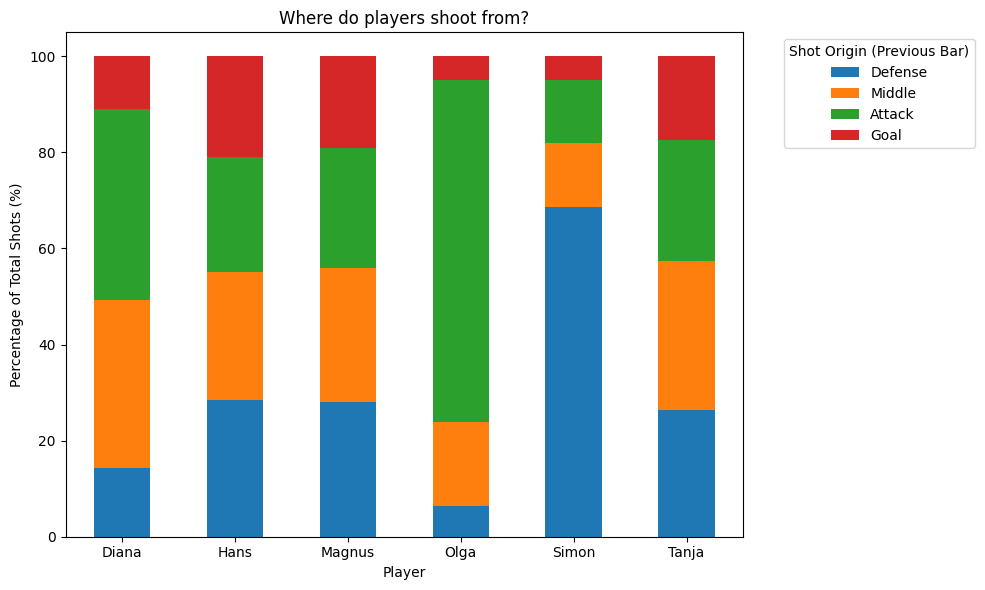

In [27]:
# Filter rows with valid previous bar
df = shot_events.dropna(subset=['prev_bar']).copy()

# Extract zone name
df['shot_zone'] = df['prev_bar'].str.extract(r'([A-Za-z]+)')

# Count shots per player per zone
counts = df.groupby(['player', 'shot_zone']).size().unstack(fill_value=0)

# Convert to percentages
zone_pct = counts.div(counts.sum(axis=1), axis=0) * 100

# Keep only relevant zones 
zones = ['Defense', 'Middle', 'Attack', 'Goal']
zone_pct = zone_pct[[z for z in zones if z in zone_pct.columns]]

# Plot
zone_pct.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title("Where do players shoot from?")
plt.ylabel("Percentage of Total Shots (%)")
plt.xlabel("Player")
plt.legend(title="Shot Origin (Previous Bar)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
print(zone_pct.round(1).reset_index().to_string(index=False))

player  Defense  Middle  Attack  Goal
 Diana     14.3    35.0    39.7  11.0
  Hans     28.5    26.5    24.0  21.0
Magnus     27.9    27.9    25.0  19.1
  Olga      6.5    17.5    71.2   4.8
 Simon     68.6    13.4    13.2   4.8
 Tanja     26.5    30.9    25.2  17.4


### Seconds held before a goal

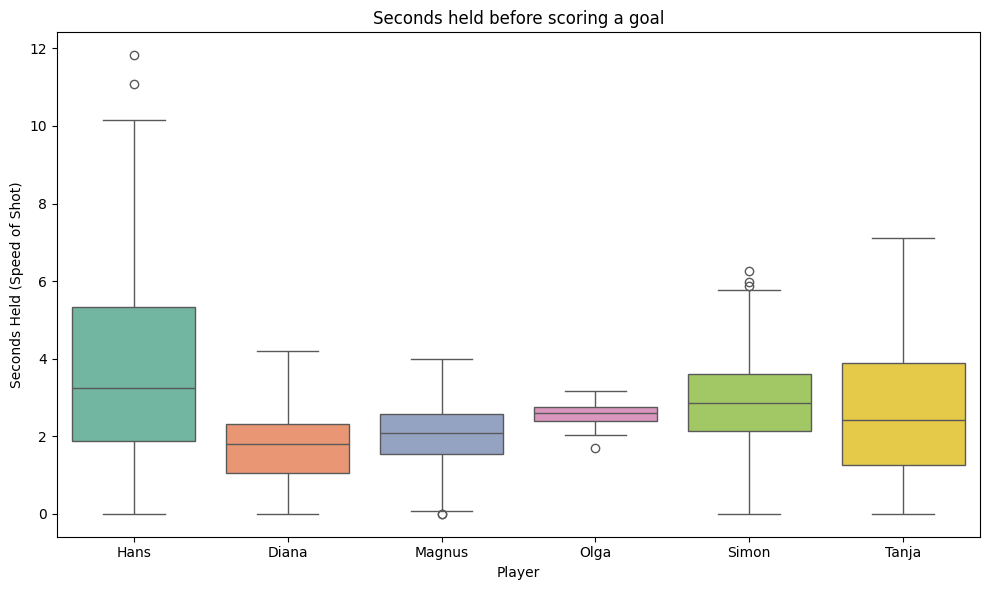

In [29]:
# Filter goals with valid previous bar
df = shot_events[shot_events['is_goal']].dropna(subset=['prev_bar']).copy()

# Compute hold time (seconds between setup and goal)
df['hold_time'] = df['timestamp'] - df['prev_timestamp']

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='player',
    y='hold_time',
    hue='player',
    palette='Set2',
    legend=False
)

plt.title("Seconds held before scoring a goal")
plt.xlabel("Player")
plt.ylabel("Seconds Held (Speed of Shot)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
# Create summary table
stats = df.groupby('player')['hold_time'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

# Print table
print(stats.to_string())

        count  mean  median   min    max
player                                  
Diana     240  1.74    1.80  0.00   4.20
Hans      162  3.58    3.25  0.00  11.82
Magnus    186  2.07    2.07  0.00   4.00
Olga      223  2.59    2.59  1.71   3.17
Simon     219  2.91    2.87  0.00   6.27
Tanja     189  2.64    2.41  0.00   7.11


In [31]:
successful_goals = shot_events[(shot_events['is_goal'])].copy()

unsuccessful_goals = shot_events[(shot_events['is_goal'] == False)].copy()

own_goals = shot_events[(shot_events['is_goal'] == True) & (shot_events['player'] != shot_events['prev_player'])].copy()

In [32]:
timestamped_data

,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,...,round,is_contact_p1,is_contact_p2,is_shot_p1,is_shot_p2,prev_player,prev_bar,prev_side,prev_event,prev_timestamp
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False,...,1,True,False,False,False,NaN,NaN,NaN,NaN,NaN
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False,...,1,True,False,False,False,Diana,Middle1,Middle,contact,2.985530
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False,...,1,False,True,False,False,Diana,Attack1,Right,contact,3.749828
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True,...,1,False,False,False,True,Hans,Attack2,Middle,contact,6.102422
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False,...,2,True,False,False,False,Hans,NaN,NaN,shot,10.453081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29332,Simon-Tanja,4,Simon,Tanja,910.737441,Tanja,contact,Defense2,Middle,False,...,1145,False,True,False,False,Tanja,Middle2,Middle,contact,906.636634
29333,Simon-Tanja,4,Simon,Tanja,911.646976,Tanja,shot,NaN,NaN,False,...,1145,False,False,False,True,Tanja,Defense2,Middle,contact,910.737441
29334,Simon-Tanja,4,Simon,Tanja,911.837511,Simon,contact,Goal1,Middle,False,...,1145,True,False,False,False,Tanja,NaN,NaN,shot,911.646976
29335,Simon-Tanja,4,Simon,Tanja,913.151401,Simon,contact,Defense1,Left,False,...,1145,True,False,False,False,Simon,Goal1,Middle,contact,911.837511


## Failed Shots / Shots Blocked Analysis

In [33]:
timestamped_data['next_player'] = timestamped_data.groupby(['game', 'run_id'])['player'].shift(-1) #same logic as above just with the following row (shift(-1))
timestamped_data['next_bar'] = timestamped_data.groupby(['game', 'run_id'])['bar'].shift(-1)
timestamped_data['next_side'] = timestamped_data.groupby(['game', 'run_id'])['side'].shift(-1)
timestamped_data['next_timestamp'] = timestamped_data.groupby(['game', 'run_id'])['timestamp'].shift(-1)

failed_shots = timestamped_data[(timestamped_data['event_type'] == 'shot') & (timestamped_data['is_goal'] == False)].copy()
failed_shots = failed_shots.drop(columns=['bar', 'side', 'is_shot', 'is_shot_p1', 'is_shot_p2', 'is_goal', 'event_type', 'is_contact_p1', 'is_contact_p2', 'round', 'prev_player'])

failed_shots['blocked_by_figure'] = (failed_shots['next_timestamp'].notna() & (failed_shots['timestamp'] == failed_shots['next_timestamp'])) #if the timestamp is the same, the shot got blocked by a figure; if not, the ball hit the wall
failed_shots['defended'] = failed_shots['blocked_by_figure'] & (failed_shots['player'] != failed_shots['next_player']) #if the ball got blocked by the opponent's figure -> defended
failed_shots['self_block'] = failed_shots['blocked_by_figure'] & (failed_shots['player'] == failed_shots['next_player']) #if the ball got blocked by the player 

In [34]:
failed_shots.head()

,game,run_id,player_1,player_2,timestamp,player,prev_bar,prev_side,prev_event,prev_timestamp,next_player,next_bar,next_side,next_timestamp,blocked_by_figure,defended,self_block
6,Diana-Hans,0,Diana,Hans,23.388610,Diana,Defense1,Left,contact,21.438754,Diana,Goal1,Middle,24.915599,False,False,False
9,Diana-Hans,0,Diana,Hans,33.182286,Hans,Attack2,Middle,contact,27.159944,Diana,Defense1,Middle,33.182286,True,True,False
11,Diana-Hans,0,Diana,Hans,35.235728,Diana,Defense1,Middle,contact,33.182286,Hans,Defense2,Middle,35.235728,True,True,False
16,Diana-Hans,0,Diana,Hans,50.007118,Hans,Goal2,Left,contact,43.598246,Diana,Attack1,Left,50.007118,True,True,False
20,Diana-Hans,0,Diana,Hans,62.824143,Hans,Middle2,Middle,contact,56.560030,Diana,Goal1,Middle,62.824143,True,True,False


In [35]:
defense_bar = failed_shots[failed_shots['defended'] == True].copy()

# Extracting just the bars (Goal, Defense, Middle, Attack)
defense_bar['shot_origin'] = defense_bar['prev_bar'].str.replace(r'\d+', '', regex=True)

# Group the data to get counts
grouped_bars = defense_bar.groupby(['shot_origin', 'player']).size().reset_index(name='count')

# Choose 2 players to get a better understanding of which bar is used by the players opponent to block their shot.
fig = px.bar(grouped_bars, x='shot_origin', y='count', 
    color='player', # Distinguishes Target Players
    barmode='group',
    title='Where did the Player Shoot From? - Defended Shots'
)
fig.show()

## Event sequence analysis

In [36]:
timestamped_data['possession_change'] = timestamped_data['player'] != timestamped_data['player'].shift()
timestamped_data['possession_id'] = timestamped_data['possession_change'].cumsum()
timestamped_data['possession_length'] = timestamped_data.groupby('possession_id').cumcount() + 1

In [37]:
timestamped_data.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,...,prev_side,prev_event,prev_timestamp,next_player,next_bar,next_side,next_timestamp,possession_change,possession_id,possession_length
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False,...,NaN,NaN,NaN,Diana,Attack1,Right,3.749828,True,1,1
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False,...,Middle,contact,2.985530,Hans,Attack2,Middle,6.102422,False,1,2
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False,...,Right,contact,3.749828,Hans,NaN,NaN,10.453081,True,2,1
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True,...,Middle,contact,6.102422,Diana,Middle1,Middle,20.291921,False,2,2
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False,...,NaN,shot,10.453081,Diana,Defense1,Left,21.438754,True,3,1


In [38]:
timestamped_data.groupby('player')['possession_length'].agg(['mean', 'std', 'min', 'max']).reset_index()

,player,mean,std,min,max
0,Diana,2.311811,1.688409,1,18
1,Hans,2.135522,1.366495,1,10
2,Magnus,2.486424,1.812207,1,17
3,Olga,3.414140,2.848917,1,24
4,Simon,2.628049,1.910739,1,21
5,Tanja,2.420588,1.794548,1,15


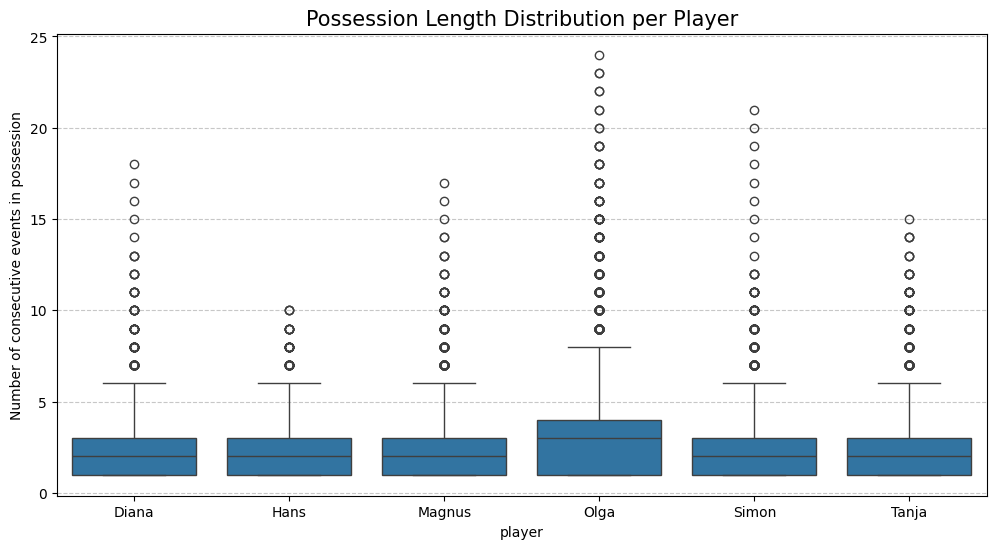

In [39]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=timestamped_data, x='player', y='possession_length')
plt.title('Possession Length Distribution per Player', fontsize=15)
plt.ylabel('Number of consecutive events in possession')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### How many consecutive events do the players possess the ball before doing a shot?

In [40]:
shot_stats = timestamped_data[timestamped_data['is_shot'] == True].groupby(['player', 'is_goal'])['possession_length'].agg(['mean', 'std', 'min', 'max']).reset_index()
shot_stats.pivot(index='player', columns='is_goal', values=['mean', 'std'])

mean                 std          
is_goal     False     True      False     True 
player                                         
Diana    3.127841  3.250000  1.633789  1.736875
Hans     2.830415  2.728395  1.284594  1.190149
Magnus   3.256127  3.419355  1.739991  1.916204
Olga     4.002268  4.197309  2.470277  2.898678
Simon    3.389904  3.347032  1.777551  2.001863
Tanja    3.087185  3.158730  1.711520  1.752260

## Extract Specific players to their respective df

In [41]:
def timestamped_player_data(player_name): #timestamped data (every event)
    player_df = timestamped_data[(timestamped_data['player_1'] == player_name) | (timestamped_data['player_2'] == player_name)]
    return player_df

In [42]:
def results_player_data(player_name): #results data -> how many points
    player_df = results_table[(results_table['player_1'] == player_name) | (results_table['player_2'] == player_name)]
    return player_df

In [43]:
def round_player_data(player_name): #round data -> aggragated until goal
    player_df = round_data[(round_data['player_1'] == player_name) | (round_data['player_2'] == player_name)]
    return player_df

In [44]:
def shot_events_player_data(player_name): #shot data -> goals and previous contact
    player_df = shot_events[(shot_events['player'] == player_name)]
    return player_df

In [45]:
def failed_shots_opponents(player_name): #failed shots of opponent -> for defense analysis
    player_df = failed_shots[(failed_shots['player_1'] == player_name) | (failed_shots['player_2'] == player_name)]
    player_df = player_df[player_df['player'] != player_name] #player who tried the shot is NOT the target player
    return player_df

In [46]:
def get_average_points(df, player_name): #calculates the mean points of a player 
    points_as_p1 = df.loc[df['player_1'] == player_name, 'points_player_1']
    points_as_p2 = df.loc[df['player_2'] == player_name, 'points_player_2']
    all_points = pd.concat([points_as_p1, points_as_p2])
    return all_points.mean()

In [47]:
def plot_player_performance(df, player_name):
    p1_mask = df['player_1'] == player_name
    case_p1 = df[p1_mask][['points_p1', 'points_p2']].rename(columns={'points_p1': 'player_p', 'points_p2': 'opponent_p'}) #when the player is player 1
    
    p2_mask = df['player_2'] == player_name
    case_p2 = df[p2_mask][['points_p2', 'points_p1']].rename(columns={'points_p2': 'player_p', 'points_p1': 'opponent_p'}) #when the player is player 2
    
    combined = pd.concat([case_p1, case_p2]) #combining both cases
    
    stats = combined.groupby('opponent_p')['player_p'].agg(['mean', 'min', 'max', 'count']).reset_index()
    
    plt.figure(figsize=(10, 5))
    
    plt.fill_between(stats['opponent_p'], #for the shadowed part around the mean line 
                     stats['min'], #the minimum player points for the amount of opponent points
                     stats['max'], #the maximum player points for the amount of opponent points
                     alpha = 0.2) #amount of transparency

    plt.plot(stats['opponent_p'], stats['mean']) #the mean line
    
    new_labels = [f"{int(row['opponent_p'])}\n(n={int(row['count'])})" for _, row in stats.iterrows()] #adding how many rows it counted 
    plt.xticks(stats['opponent_p'], new_labels)
    
    plt.title(f"Average points of {player_name} (incl. min and max) against opponent's points")
    plt.xlabel("Opponent's points")
    plt.ylabel(f"Points of {player_name}")
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

In [48]:
def plot_shot_heatmap(df, player_name, mode='success'):
    """
    mode: 'success' (successful shots by player), 'unsuccessful' (unsuccessful shots by player), 'defense' (unsuccessful shots by opponent which got blocked by the player)
    """
    plot_data = df.copy()

    if mode == 'success':
        plot_data = plot_data[plot_data['is_goal'] == True] #only successful shots
        title_type = "Successful shots (goals)"
        bar_col, side_col = 'prev_bar', 'prev_side'

    elif mode == 'unsuccessful':
        plot_data = plot_data[plot_data['is_goal'] == False].copy() #only unsuccessful shots
        title_type = "Unsuccessful shots"
        bar_col, side_col = 'prev_bar', 'prev_side'

    elif mode == 'defense':
        plot_data = plot_data[plot_data['defended'] == True] #only defended shots
        title_type = "Defended opponent shots"
        bar_col, side_col = 'next_bar', 'next_side'
    
    def fix_side_perspective(row): #mirroring the sides if the player is player 2
        if row['player_2'] == player_name:
            if row[side_col] == 'Left': return 'Right'
            if row[side_col] == 'Right': return 'Left'
        return row[side_col]

    plot_data['side_fixed'] = plot_data.apply(fix_side_perspective, axis=1)
    plot_data['bar_clean'] = plot_data[bar_col].str.replace(r'\d+', '', regex=True) #removing the "1" or the "2" at the end of the bar name

    bar_order = ['Attack', 'Middle', 'Defense', 'Goal']
    side_order = ['Left', 'Middle', 'Right']
    
    counts = plot_data.groupby(['bar_clean', 'side_fixed']).size().unstack(fill_value=0)
    heatmap_data = counts.reindex(index=bar_order, columns=side_order, fill_value=0)
    
    total_actions = heatmap_data.values.sum()
    heatmap_percent = (heatmap_data / total_actions) * 100

    plt.figure(figsize=(7, 4))
    sns.heatmap(
        heatmap_percent, 
        annot=True, 
        fmt=".1f",
        cbar=False, 
        cmap="Reds",
        linewidths=1.5,
        linecolor='white')
    
    plt.title(f"{title_type}: {player_name}\n({int(total_actions)} total actions)", pad=15)
    plt.xlabel("")
    plt.ylabel("")

    for t in plt.gca().texts:
        t.set_text(t.get_text() + "%")
    
    plt.gca().xaxis.tick_top()
    plt.gca().xaxis.set_label_position('top')
    
    plt.tight_layout()
    plt.show()

In [49]:
#creating a function to analyze the shot paths of the players -> which bars do they use before taking a shot and how successful are they with that
def analyze_player_shot_paths(df):
    plot_data = df.copy()
    plot_data['bar'] = plot_data['bar'].str.replace(r'\d+', '', regex=True) #removing "1" or "2" at the end of the bar name
    
    shot_possessions = plot_data[plot_data['is_shot'] == True]['possession_id'].unique() #identifying the possessions that ended with a shot
    shot_data = plot_data[plot_data['possession_id'].isin(shot_possessions)].copy() 
    
    def get_path(group):
        path_bars = group[group['is_shot'] == False]['bar'].tolist()
        return " -> ".join(path_bars) if path_bars else "Direct Shot" #combining the bars into a path, if there are no bars -> direct shot

    paths = shot_data.groupby('possession_id').agg(
        path=('bar', lambda x: get_path(shot_data.loc[x.index])), #applying the get_path function to each possession_id group to get the path of bars leading to the shot
        goal=('is_goal', 'max'))
    
    path_stats = paths.groupby('path').agg( #grouping by the path to get the frequency and success rate for each path
        frequency=('goal', 'count'),
        success_rate=('goal', 'mean')).reset_index()
    
    path_stats['path_filtered'] = path_stats.apply(
        lambda x: x['path'] if x['frequency'] > 14 else 'Rare Path', #each path has to be taken at least 15 times to be shown separately, otherwise it gets categorized as "Rare Path"
        axis=1)
    
    final_stats = path_stats.groupby('path_filtered').agg( #grouping by the filtered paths to get the final frequency and success rate for each path
        frequency=('frequency', 'sum'),
        success_rate=('success_rate', lambda x: (x * path_stats.loc[x.index, 'frequency']).sum() / path_stats.loc[x.index, 'frequency'].sum())
    ).reset_index()
    
    total_shots = final_stats['frequency'].sum()
    
    return final_stats.sort_values(by='frequency', ascending=False).reset_index(drop=True) #sorting by frequency (most common paths first)

### <span style="color:green"> **--- Player: Diana ---**</span>

In [50]:
timestamped_data_diana = timestamped_player_data('Diana')
results_data_diana = results_player_data('Diana')
round_data_diana = round_player_data('Diana')
shot_events_diana = shot_events_player_data('Diana')
defense_data_diana = failed_shots_opponents('Diana')

In [51]:
print(get_average_points(results_data_diana, 'Diana'))

9.6


In [52]:
print(defense_data_diana['defended'].mean())

0.6128236744759556


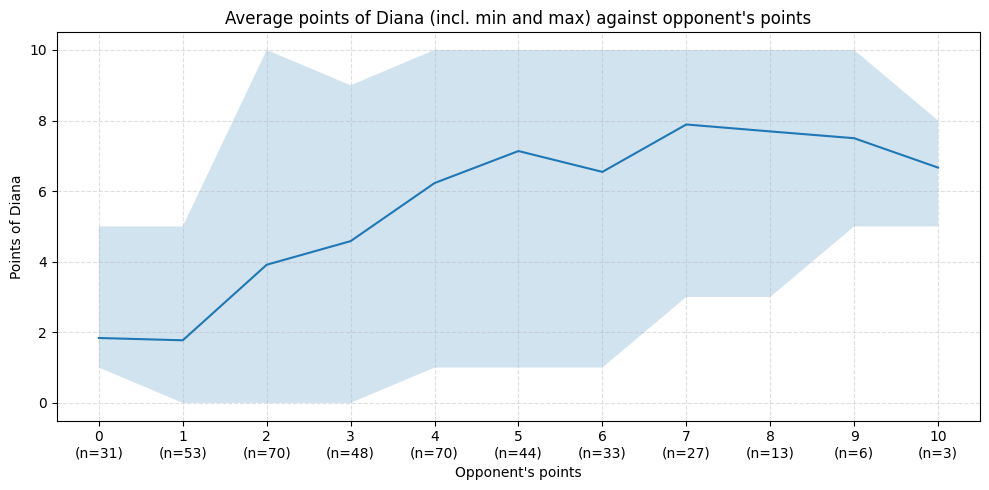

In [53]:
plot_player_performance(round_data_diana, 'Diana')

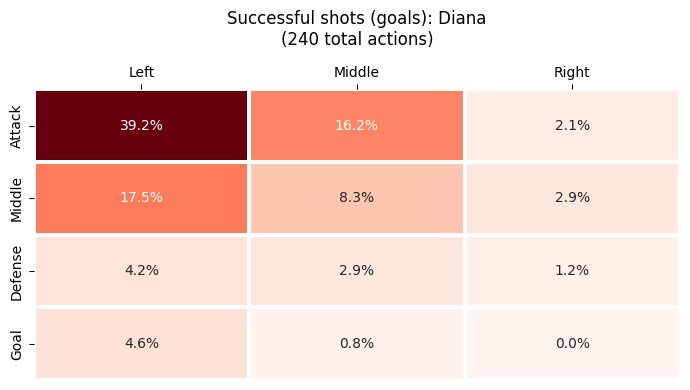

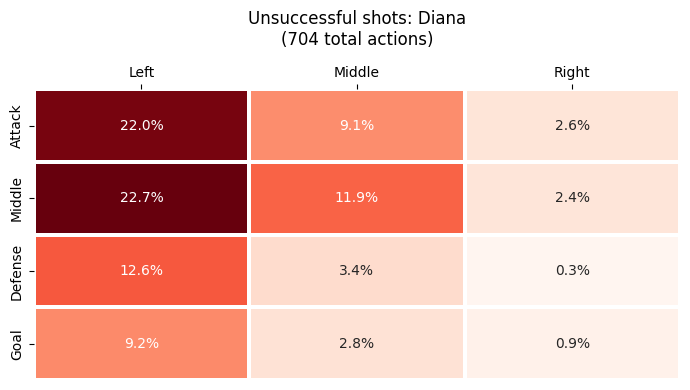

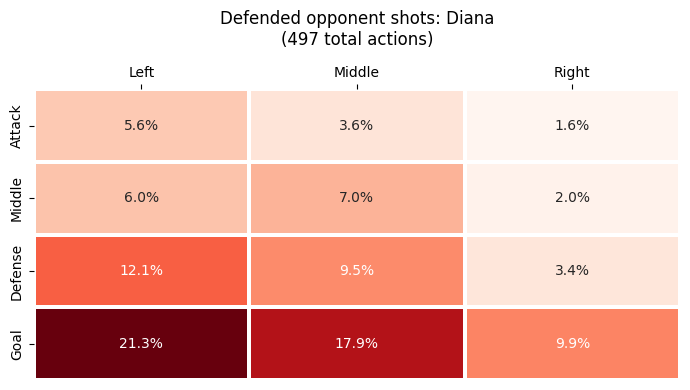

In [54]:
plot_shot_heatmap(shot_events_diana, 'Diana')
plot_shot_heatmap(shot_events_diana, 'Diana', mode ='unsuccessful')
plot_shot_heatmap(defense_data_diana, 'Diana', mode = 'defense')

### The total number of events (contacts and shots) for Diana and Hans

In [55]:
# Count total events per player
total_activity = timestamped_data["player"].value_counts().reset_index()
total_activity.columns = ["player", "total_events"]  # rename columns

# keep only Diana and Hans
dh_activity = total_activity[total_activity["player"].isin(["Diana", "Hans"])].copy()

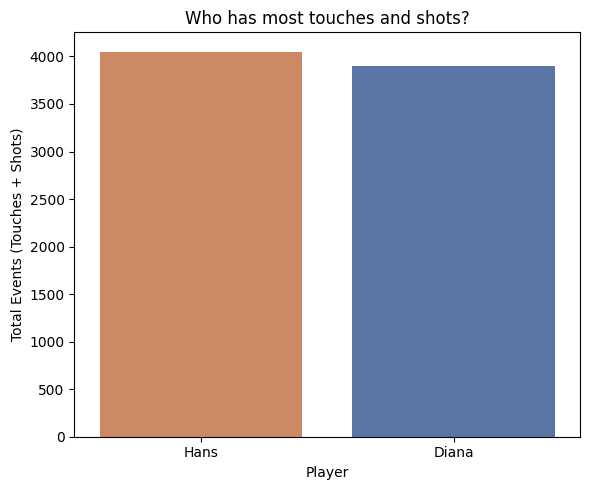

In [56]:
# Create figure
plt.figure(figsize=(6, 5))

# Bar plot
sns.barplot(data=dh_activity, x="player", y="total_events", hue="player", palette=["#DD8452", "#4C72B0"], legend=False)

# Add title and labels
plt.title("Who has most touches and shots?")
plt.xlabel("Player")
plt.ylabel("Total Events (Touches + Shots)")

plt.tight_layout()
plt.show()

Diana has fewer total events than Hans despite winning 19 more games.

### How often does Diana and Hans play on the left, middle or right side of the table?

In [57]:
# Keep only contact events with valid side and player
contacts_only = timestamped_data[(timestamped_data["event_type"] == "contact") & 
                                 (timestamped_data["side"].notna()) &
                                 (timestamped_data["player"].isin(["Diana", "Hans"]))].copy()

# Count contacts per side
side_counts = contacts_only.groupby(["player", "side"]).size().unstack(fill_value=0)

# convert to percentages
side_pct = side_counts.div(side_counts.sum(axis=1), axis=0) * 100

# Order sides
side_pct = side_pct[["Left", "Middle", "Right"]]

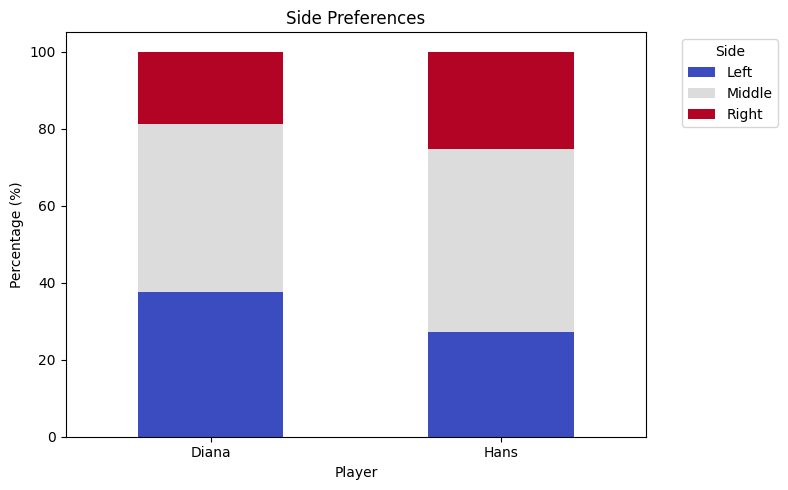

In [58]:
# Stacked bar chart
side_pct.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="coolwarm")

# Add title and labels
plt.title("Side Preferences")
plt.ylabel("Percentage (%)")
plt.xlabel("Player")

# Show legend
plt.legend(title="Side", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Ratio of contacts to shots (Useful to see how often each player passes before shooting?)

In [59]:
# Count contacts and shots per player
event_counts = timestamped_data[timestamped_data["player"].isin(["Diana", "Hans"])].groupby(["player", "event_type"]).size().unstack()

# Compute contacts per shot ratio
event_counts["touches_per_shot"] = event_counts["contact"] / event_counts["shot"]

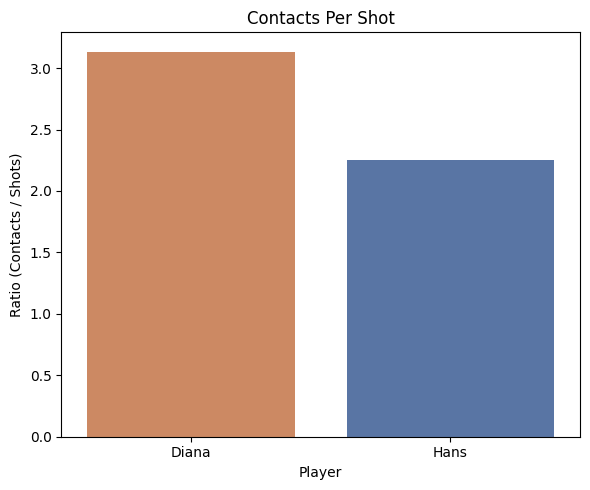

In [60]:
plt.figure(figsize=(6, 5))

# plot ratio
sns.barplot(x=event_counts.index, y=event_counts["touches_per_shot"], hue=event_counts.index,
            palette=["#DD8452", "#4C72B0"], legend=False)

plt.title("Contacts Per Shot")
plt.xlabel("Player")
plt.ylabel("Ratio (Contacts / Shots)")

plt.tight_layout()
plt.show()

### Diana's wins and losses against each opponent

In [61]:
# Keep games where Diana played
diana_games = results_table[(results_table["winner"] == "Diana") | (results_table["loser"] == "Diana")].copy()

# Count wins and losses
diana_wins = diana_games[diana_games["winner"] == "Diana"]["loser"].value_counts().rename("Wins")
diana_losses = diana_games[diana_games["loser"] == "Diana"]["winner"].value_counts().rename("Losses")

# combine into one table
diana_record = pd.concat([diana_wins, diana_losses], axis=1).fillna(0)

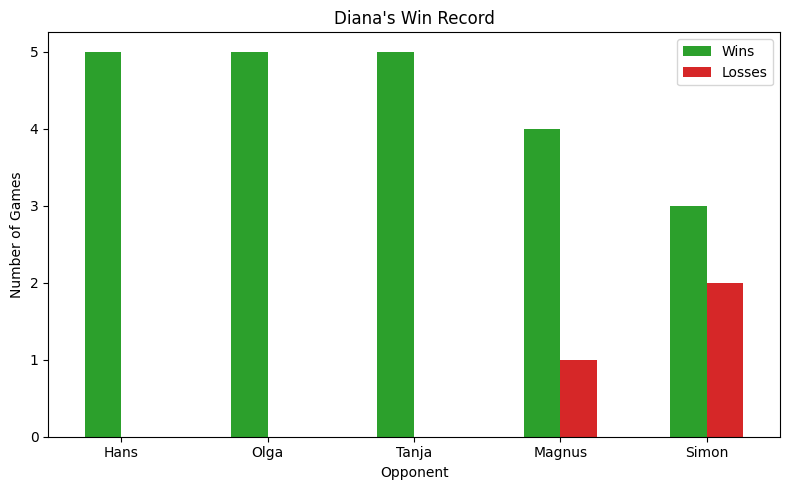

In [62]:
# Plot results
diana_record.plot(kind="bar", figsize=(8, 5), color=["#2ca02c", "#d62728"])

# add title and labels
plt.title("Diana's Win Record")
plt.xlabel("Opponent")
plt.ylabel("Number of Games")
plt.xticks(rotation=0)
plt.legend(["Wins", "Losses"])

plt.tight_layout()
plt.show()

### What percentage of shots actually result in a goal from each table zone

In [63]:
# Keep shots with known origin zone
shots_with_zone = shot_events.dropna(subset=["prev_bar"]).copy()

# Extract zone name from text
shots_with_zone["shot_zone"] = shots_with_zone["prev_bar"].str.extract(r"([A-Za-z]+)")

# Keep only Diana and Hans
dh_accuracy = shots_with_zone[shots_with_zone["player"].isin(["Diana", "Hans"])]

# Compute goal percentage per player and zone
zone_success = (dh_accuracy.groupby(["player", "shot_zone"])["is_goal"].mean().unstack() * 100)

# Order zones
valid_acc_zones = [c for c in ["Defense", "Middle", "Attack"] if c in zone_success.columns]
zone_success = zone_success[valid_acc_zones]

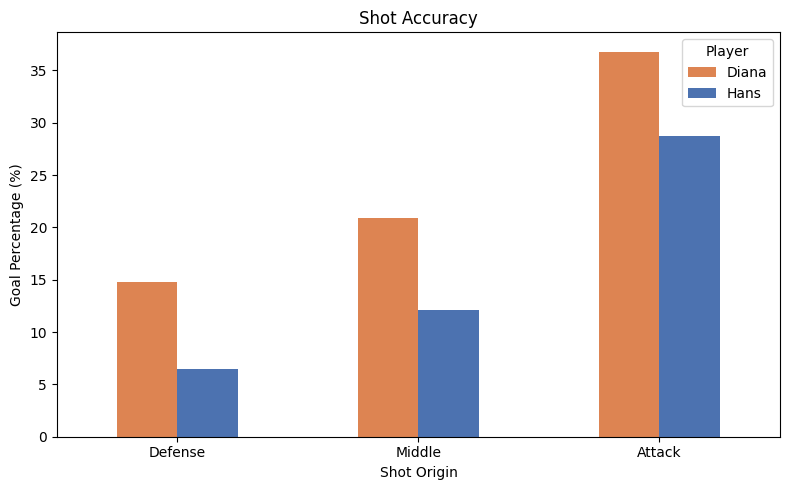

In [64]:
# plot accuracy per zone
zone_success.T.plot(kind="bar", figsize=(8, 5), color=["#DD8452", "#4C72B0"])

# Add labels
plt.title("Shot Accuracy")
plt.xlabel("Shot Origin")
plt.ylabel("Goal Percentage (%)")

plt.xticks(rotation=0)
plt.legend(title="Player")
plt.tight_layout()
plt.show()

### Average length of a match (in seconds) when Diana plays versus when Hans plays

In [65]:
# Get total duration per match
match_lengths = timestamped_data.groupby(["game", "run_id"])["timestamp"].max().reset_index()
match_lengths.columns = ["game", "run_id", "total_seconds"]

# Filter Diana matches
diana_matches = match_lengths[match_lengths["game"].str.contains("Diana")].copy()
diana_matches["player"] = "Diana Matches"

# Filter Hans matches
hans_matches = match_lengths[match_lengths["game"].str.contains("Hans")].copy()
hans_matches["player"] = "Hans Matches"

# Combine both datasets
combined_lengths = pd.concat([diana_matches, hans_matches])

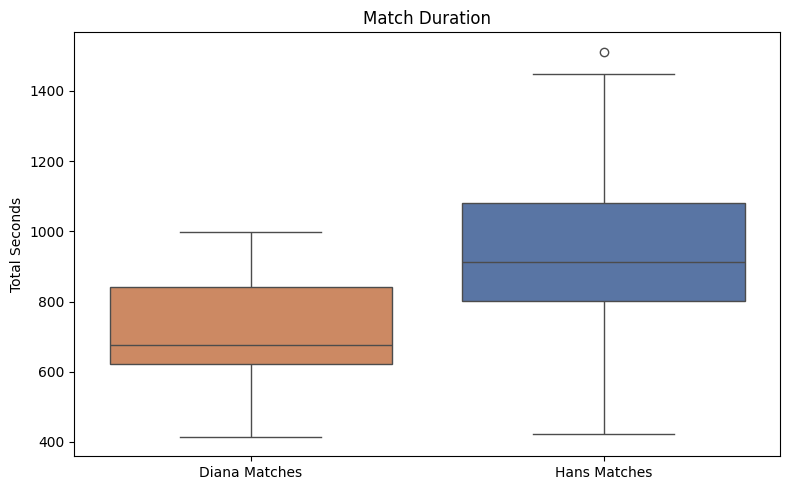

In [66]:
plt.figure(figsize=(8, 5))

# Boxplot for match duration
sns.boxplot(data=combined_lengths, x="player", y="total_seconds", hue="player",
            palette=["#DD8452", "#4C72B0"], legend=False)

# add title and labels
plt.title("Match Duration")
plt.xlabel("")
plt.ylabel("Total Seconds")

plt.tight_layout()
plt.show()

### <span style="color:purple"> **---Player: Hans---**</span>

In [ ]:
# EDA & Function for Hans

In [ ]:
timestamped_data_hans = timestamped_player_data('Hans')
results_data_hans = results_player_data('Hans')
round_data_hans = round_player_data('Hans')
shot_events_hans = shot_events_player_data('Hans')
defense_data_hans = failed_shots_opponents('Hans')

In [ ]:
plot_player_performance(round_data_hans, 'Hans')

In [ ]:
print(get_average_points(results_data_hans, 'Hans'))

In [ ]:
print(defense_data_hans['defended'].mean())

In [ ]:
plot_shot_heatmap(shot_events_hans, 'Hans', mode = 'success')
plot_shot_heatmap(shot_events_hans, 'Hans', mode ='unsuccessful')
plot_shot_heatmap(defense_data_hans, 'Hans', mode = 'defense')

### <span style="color:orange"> **---Player: Simon ---**</span>

In [ ]:
timestamped_data_simon = timestamped_player_data('Simon')
results_data_simon = results_player_data('Simon')
round_data_simon = round_player_data('Simon')
shot_events_simon = shot_events_player_data('Simon')
defense_data_simon = failed_shots_opponents('Simon')

## Head to Head stats for Simon vs All

In [ ]:
df_results = results_player_data('Simon').copy() # Safe copy
df_results['opponent'] = np.where(df_results['player_1'] == 'Simon', df_results['player_2'], df_results['player_1'])
df_results['Points-Simon'] = np.where(df_results['player_1'] == 'Simon', df_results['points_player_1'], df_results['points_player_2'])

fig = px.box(df_results, x='opponent', y='Points-Simon', color='opponent', title="Simon's Point Scored Per Game vs Specific Opponents")
fig.show()

What can be inferred from the above plots?:
- **(Q1)** scores or the 25 percentile scores show that **Simon in 25%** of the games scored **more than 6 points** against **Magnus, Olga, Hans and Tanja.** Against **Diana** who was his **strongest opponent** he has a q1 score of 5 points (lowest).
- **(Q3)** scores or the 75 percentile scores show that simon had 10 points in most of his games against Magnus, Olga, Tanja & Hans, which shows he was also a dominant player however against Diana he did have a q3 value of 10 but his **median value against Diana was an 8**, which shows that Diana was able to prevent him from reaching his perfect score of 10 a few times.  

In [ ]:
df_rounds = round_player_data('Simon').copy()

df_rounds['opponent'] = np.where(df_rounds['player_1'] == 'Simon', df_rounds['player_2'], df_rounds['player_1'])

fig = px.box(df_rounds, x='opponent', y='duration', color='opponent', title="Pace of Game: Simon's Round Durations vs his Opponents", labels={'duration': 'Duration ( in Seconds)'})
fig.show()

In [ ]:
plot_shot_heatmap(shot_events_simon, 'Simon', mode = 'success')
plot_shot_heatmap(shot_events_simon, 'Simon', mode ='unsuccessful')
plot_shot_heatmap(defense_data_simon, 'Simon', mode = 'defense')

### <span style="color:brown"> **--- Player: Olga---**</span>

In [ ]:
timestamped_data_olga = timestamped_player_data('Olga')
results_data_olga = results_player_data('Olga')
round_data_olga = round_player_data('Olga')
shot_events_olga = shot_events_player_data('Olga')
defense_data_olga = failed_shots_opponents('Olga')

In [ ]:
print(get_average_points(results_data_olga, 'Olga'))

In [ ]:
print(defense_data_olga['defended'].mean())

In [ ]:
plot_player_performance(round_data_olga, 'Olga')

In [ ]:
plot_shot_heatmap(shot_events_olga, 'Olga', mode = 'success')
plot_shot_heatmap(shot_events_olga, 'Olga', mode ='unsuccessful')
plot_shot_heatmap(defense_data_olga, 'Olga', mode = 'defense')

### <span style="color:lightblue"> **--- Player: Magnus---**</span>

In [ ]:
timestamped_data_magnus = timestamped_player_data('Magnus')
results_data_magnus = results_player_data('Magnus')
round_data_magnus = round_player_data('Magnus')
shot_events_magnus = shot_events_player_data('Magnus')
defense_data_magnus = failed_shots_opponents('Magnus')

In [ ]:
print(get_average_points(results_data_magnus, 'Magnus'))

In [ ]:
print(defense_data_magnus['defended'].mean())

In [ ]:
plot_player_performance(round_data_magnus, 'Magnus')

In [ ]:
plot_shot_heatmap(shot_events_magnus, 'Magnus', mode = 'success')
plot_shot_heatmap(shot_events_magnus, 'Magnus', mode ='unsuccessful')
plot_shot_heatmap(defense_data_magnus, 'Magnus', mode = 'defense')

In [ ]:
analyze_player_shot_paths(timestamped_data_magnus)

### <span style="color:pink"> **---Player: Tanja---**</span>

In [ ]:
timestamped_data_tanja = timestamped_player_data('Tanja')
results_data_tanja = results_player_data('Tanja')
round_data_tanja = round_player_data('Tanja')
shot_events_tanja = shot_events_player_data('Tanja')
defense_data_tanja = failed_shots_opponents('Tanja')

In [ ]:
print(get_average_points(results_data_tanja, 'Tanja'))

In [ ]:
print(defense_data_tanja['defended'].mean())

In [ ]:
plot_player_performance(round_data_tanja, 'Tanja')

In [ ]:
plot_shot_heatmap(shot_events_tanja, 'Tanja', mode = 'success')
plot_shot_heatmap(shot_events_tanja, 'Tanja', mode ='unsuccessful')
plot_shot_heatmap(defense_data_tanja, 'Tanja', mode = 'defense')

In [ ]:
analyze_player_shot_paths(timestamped_data_tanja)